# 📈 Linear Regression: Custom GD vs. Custom OLS vs. Scikit-Learn

This notebook performs Exploratory Data Analysis (EDA) on the Medical Cost Personal Dataset and compares three linear regression implementations side by side:
1. **Custom Gradient Descent (GD)** — Built from scratch using NumPy.
2. **Custom Ordinary Least Squares (OLS)** — Built from scratch using closed-form normal equations.
3. **Scikit-Learn `LinearRegression`** — Standard baseline library model.

## 1. Imports & Environment Setup

In [1]:
# Necessary Modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities for comparison
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#Sklearn necessary training module
from sklearn.linear_model import LinearRegression

## 2. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('insurance.csv')

print("Dataset Shape:", df.shape, "\n")
print("Missing Values:\n", df.isnull().sum(), "\n")
df.head()

Dataset Shape: (1338, 7) 

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64 



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Exploratory Data Analysis (EDA)

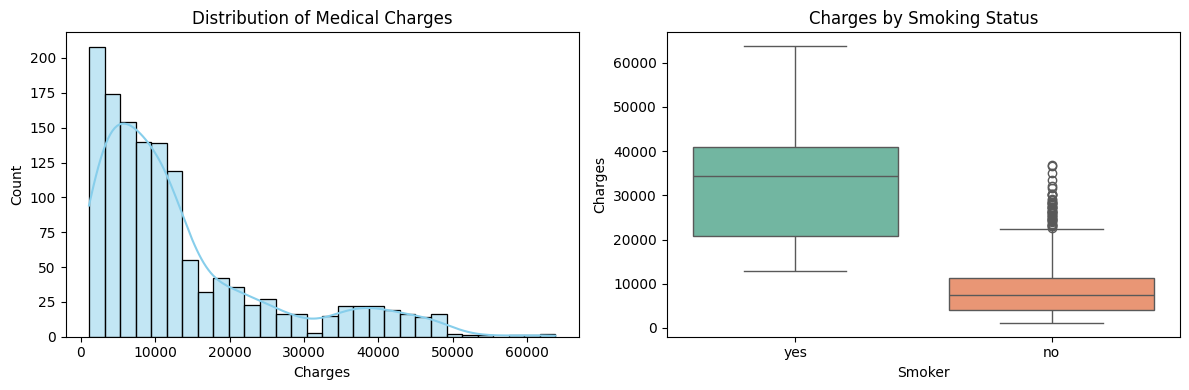

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. Distribution of target variable (Charges)
sns.histplot(df['charges'], kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribution of Medical Charges')
ax1.set_xlabel('Charges')
ax1.set_ylabel('Count')

# 2. Smoker vs Charges interaction
sns.boxplot(
    x='smoker', 
    y='charges', 
    data=df, 
    hue='smoker', 
    palette='Set2', 
    legend=False, 
    ax=ax2
)
ax2.set_title('Charges by Smoking Status')
ax2.set_xlabel('Smoker')
ax2.set_ylabel('Charges')

fig.savefig('eda_medical_charges.png', dpi=300, bbox_inches='tight')
fig.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing
* **Categorical Encoding:** One-hot encoding applied to `sex`, `smoker`, and `region`.
* **Data Splitting:** 80% Training / 20% Testing split.
* **Feature Scaling:** `StandardScaler` applied to prevent feature dominance in Gradient Descent.

In [4]:
# Convert categorical features into numerical (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [5]:
# Separate features (X) and target (y)
X = df_encoded.drop('charges', axis=1).values
y = df_encoded['charges'].values

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Essential for Gradient Descent convergence!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (1070, 8)
X_test shape: (268, 8)


## 5. Model Implementations From Scratch

### 5.1 Custom Linear Regression using Gradient Descent

In [6]:
# Linear Regression with GD

class LinearRegressionGD:
    def __init__( self, learning_rate=0.01, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def fit(self, X, y): # X_train, y_train

        #STEP 1 - initialize
        m, n= X.shape
        self.bias = 0
        self.weights = np.zeros(n)
        
        # Gradient Descent
        for i in range(self.n_iter):
            #STEP 2 - Cal y_pred
            y_pred = self.bias + np.dot(X, self.weights)
    
            #STEP 3 - cal gradient
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))
    
            #STEP 4 - Convergence Theorem - Params update
            self.bias -= self.lr * db
            self.weights -= self.lr * dw 
        

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

### 5.2 Custom Linear Regression using OLS (Normal Equation)

In [7]:
# Linear Regression Using OLS

class LinearRegressionOLS:
    def __init__(self):
        self.bias = None
        self.weights = None

    def fit(self, X, y):

        m, n= X.shape
        X_b = np.c_[np.ones((m, 1)) ,X]
        theta = np.dot( np.linalg.inv(np.dot(X_b.T, X_b)), np.dot(X_b.T, y))
        self.bias = theta[0]
        self.weights = theta[1:]
        

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

## 6. Model Training & Evaluation

In [8]:
gd_model = LinearRegressionGD(learning_rate=0.01, n_iter=2000)
ols_model = LinearRegressionOLS()
sklearn_model = LinearRegression()

In [9]:
gd_model.fit(X_train_scaled, y_train)
ols_model.fit(X_train_scaled, y_train)
sklearn_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred_gd = gd_model.predict(X_test_scaled)
y_pred_ols = ols_model.predict(X_test_scaled)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

In [11]:
def get_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

results = {
    "Model": ["Custom GD", "Custom OLS", "Scikit-Learn OLS"],
    "R2 Score": [
        get_metrics(y_test, y_pred_gd)[0],
        get_metrics(y_test, y_pred_ols)[0],
        get_metrics(y_test, y_pred_sklearn)[0]
    ],
    "MAE": [
        get_metrics(y_test, y_pred_gd)[1],
        get_metrics(y_test, y_pred_ols)[1],
        get_metrics(y_test, y_pred_sklearn)[1]
    ],
    "RMSE": [
        get_metrics(y_test, y_pred_gd)[2],
        get_metrics(y_test, y_pred_ols)[2],
        get_metrics(y_test, y_pred_sklearn)[2]
    ]
}

In [12]:
df_results = pd.DataFrame(results)
df_results

,Model,R2 Score,MAE,RMSE
0,Custom GD,0.783590,4181.226067,5796.323154
1,Custom OLS,0.783593,4181.194474,5796.284659
2,Scikit-Learn OLS,0.783593,4181.194474,5796.284659


## 7. Results & Key Takeaways

| Model | $R^2$ Score | MAE | RMSE |
| :--- | :--- | :--- | :--- |
| **Custom GD** | ~0.783590 | ~4181.23 | ~5796.32 |
| **Custom OLS** | ~0.783593 | ~4181.19 | ~5796.28 |
| **Scikit-Learn OLS** | ~0.783593 | ~4181.19 | ~5796.28 |

### Summary:
* **Custom OLS vs Scikit-Learn:** The matrix formula $(\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$ implementation produces exact results down to 6 decimal places, validating the manual closed-form linear algebra logic.
* **Gradient Descent Convergence:** With standard scaling and appropriate learning parameters ($\alpha = 0.01$), iterative Gradient Descent successfully converged to within $0.000003$ $R^2$ score of the true minimum.